# Project 5 — Module 6: Supervised Machine Learning
## Lesson 8: Gradient Boosting & Final Model Deployment

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 6 — Deployment |
| **Module** | 6 — Supervised Machine Learning (Alkemy Bootcamp) |
| **Dataset** | PequeShop — customers_final.csv + transactions_final.csv |
| **Date** | 2026-03 |

---

> **Executive Summary:**  
> This notebook implements GradientBoostingRegressor (L8), compares it
> against the best model from notebook 05, selects and justifies the
> final model, and translates results into prioritized business
> recommendations. The final model artifact is saved for deployment.


## Table of Contents

1. [CRISP-DM Phase 6 — Deployment](#1-crisp-dm-phase-6--deployment)
2. [Load Data & Models](#2-load-data--models)
3. [GradientBoosting — Training & Optimization](#3-gradientboosting--training--optimization)
4. [Ensemble Advantages & Limitations](#4-ensemble-advantages--limitations)
5. [Final Model Comparison](#5-final-model-comparison)
6. [Final Model Selection & Justification](#6-final-model-selection--justification)
7. [Consigna Response — avg_ticket Prediction](#7-consigna-response--avg_ticket-prediction)
   - [7a. Predictions — Test Set](#7a-predictions--test-set)
   - [7b. Real vs Predicted — Scatter](#7b-real-vs-predicted--scatter)
   - [7c. Customer Segmentation by Predicted Spend](#7c-customer-segmentation-by-predicted-spend)
8. [Business Recommendations — Lean Priority Order](#8-business-recommendations--lean-priority-order)
9. [MLOps Checklist](#9-mlops-checklist)
10. [Future Enhancements](#10-future-enhancements)
11. [LEAN Filter — Waste Elimination Review](#11-lean-filter--waste-elimination-review)
12. [Decisions Log — Lesson 8](#12-decisions-log--lesson-8)
13. [Project Retrospective — CRISP-DM Cycle Complete](#13-project-retrospective--crisp-dm-cycle-complete)


In [10]:
# ===== Environment Setup =====

import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# Python utilities
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Model persistence
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
MODELS_PATH     = Path('../models')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures


---
## 1. CRISP-DM Phase 6 — Deployment

### 1.1 Deployment in ML Context

Deployment means delivering a model that is:
- **Reproducible** — same results on any machine
- **Justified** — decision backed by evidence
- **Actionable** — connected to real business decisions

### 1.2 What GradientBoosting Adds

| Aspect | Linear/Ridge/Lasso | GradientBoosting |
|--------|-------------------|------------------|
| Model type | Single linear model | Ensemble of weak learners |
| Non-linearity | Only via Polynomial | Captures complex interactions |
| Interpretability | High (coefficients) | Lower (feature importance) |
| Overfitting risk | Low-Medium | Higher — requires tuning |
| Training speed | Fast | Slower |
| Typical performance | Good baseline | Often best for tabular data |


---
## 2. Load Data & Best Model from Notebook 05


In [11]:
# ===== Load Data =====
df_customers    = pd.read_csv(DATA_PROCESSED / 'customers_final.csv')
df_transactions = pd.read_csv(DATA_PROCESSED / 'transactions_final.csv')

platform_map = (
    df_transactions.groupby('customer_id')['platform']
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'platform': 'primary_platform'})
)
df_merged = df_customers.merge(platform_map, on='customer_id', how='left')

CATEGORICAL_FEATURES = ['primary_platform', 'retargeting_segment']
NUMERIC_FEATURES     = ['total_transactions', 'total_revenue']
TARGET               = 'avg_ticket'

df_model = df_merged[CATEGORICAL_FEATURES + NUMERIC_FEATURES + [TARGET]].dropna()
X = df_model[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Load preprocessor and best models from notebooks 03-05
preprocessor = joblib.load(MODELS_PATH / 'preprocessor_v1.pkl')
pipe_lr      = joblib.load(MODELS_PATH / 'model_lr_v1.pkl')
pipe_poly    = joblib.load(MODELS_PATH / 'model_poly_v1.pkl')
pipe_ridge   = joblib.load(MODELS_PATH / 'model_ridge_v1.pkl')
pipe_lasso   = joblib.load(MODELS_PATH / 'model_lasso_v1.pkl')
pipe_knn_opt = joblib.load(MODELS_PATH / 'model_knn_optimized_v1.pkl')

# Baseline
y_pred_baseline = np.full(len(y_test), y_train.mean())
baseline_r2     = r2_score(y_test, y_pred_baseline)
baseline_mae    = mean_absolute_error(y_test, y_pred_baseline)

print('Data and models loaded ✅')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

Data and models loaded ✅
X_train: (313, 4) | X_test: (79, 4)


---
## 3. GradientBoosting — Training & Optimization


In [12]:
# ===== GradientBoosting Pipeline =====
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

param_grid_gb = {
    'model__n_estimators' : [100, 200],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth'    : [2, 3, 4]
}

gs_gb = GridSearchCV(
    pipe_gb, param_grid_gb, cv=kf,
    scoring='r2', n_jobs=-1, verbose=1
)
gs_gb.fit(X_train, y_train)

print()
print(f'Best params : {gs_gb.best_params_}')
print(f'Best CV R²  : {gs_gb.best_score_:.4f}')

y_pred_train_gb = gs_gb.best_estimator_.predict(X_train)
y_pred_test_gb  = gs_gb.best_estimator_.predict(X_test)

gb_metrics = {
    'MAE test'  : round(mean_absolute_error(y_test,  y_pred_test_gb),  2),
    'RMSE test' : round(np.sqrt(mean_squared_error(y_test,  y_pred_test_gb)),  2),
    'R2 train'  : round(r2_score(y_train, y_pred_train_gb), 4),
    'R2 test'   : round(r2_score(y_test,  y_pred_test_gb),  4),
    'Overfit gap': round(r2_score(y_train, y_pred_train_gb) - r2_score(y_test, y_pred_test_gb), 4)
}

print()
print('GRADIENT BOOSTING — Results')
for k, v in gb_metrics.items():
    unit = ' CLP' if 'MAE' in k or 'RMSE' in k else ''
    print(f'  {k:<15}: {v}{unit}')

joblib.dump(gs_gb.best_estimator_, MODELS_PATH / 'model_gb_v1.pkl')
print('\n✅ GradientBoosting saved: models/model_gb_v1.pkl')

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best params : {'model__learning_rate': 0.2, 'model__max_depth': 2, 'model__n_estimators': 200}
Best CV R²  : 0.9471

GRADIENT BOOSTING — Results
  MAE test       : 1185.05 CLP
  RMSE test      : 1667.89 CLP
  R2 train       : 0.9975
  R2 test        : 0.9772
  Overfit gap    : 0.0202

✅ GradientBoosting saved: models/model_gb_v1.pkl


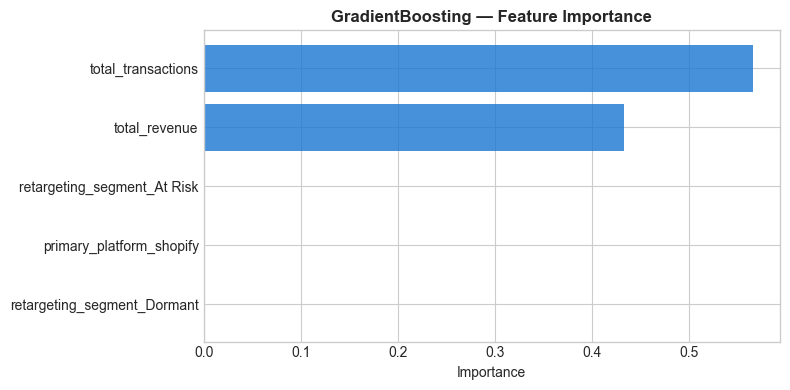

Figure saved: ..\reports\figures\06_gb_feature_importance.png


In [13]:
# ===== Feature Importance — GradientBoosting =====
gb_model      = gs_gb.best_estimator_.named_steps['model']
prep          = gs_gb.best_estimator_.named_steps['preprocessor']
cat_names     = prep.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = list(cat_names) + NUMERIC_FEATURES

df_importance = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_importance['Feature'], df_importance['Importance'],
        color='#1976D2', alpha=0.8)
ax.set_title('GradientBoosting — Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
out = REPORTS_FIGURES / '06_gb_feature_importance.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

---
## 4. Ensemble Advantages & Limitations

### Advantages of GradientBoosting

- Captures non-linear relationships and feature interactions automatically
- Generally outperforms linear models on tabular data
- Robust to outliers compared to simple linear regression
- Feature importance provides insight into which variables drive predictions

### Limitations

- Less interpretable than linear models — coefficients are not directly readable
- Risk of overfitting with small datasets (n=392) — requires careful hyperparameter tuning
- Slower to train than linear models
- With synthetic data and few features, improvement over Ridge/Lasso may be marginal

> **Key insight for PequeShop:** If GradientBoosting does not significantly
> outperform Ridge on this synthetic dataset, the simpler Ridge model is
> preferred — it is more interpretable and less prone to overfitting.
> This is the Lean principle: use the simplest model that meets the objective.


---
## 5. Final Model Comparison


FINAL MODEL COMPARISON — All Models


,Model,MAE test,RMSE test,MAPE test %,R2 train,R2 test,Overfit gap,Meets R²>0.70?,Beats baseline?
5,GradientBoosting,1185.05,1667.89,3.71,0.9975,0.9772,0.0202,True,True
1,Polynomial (deg=2),3114.84,4469.80,11.33,0.9003,0.8364,0.0639,True,True
4,KNN (optimized),3038.25,5840.58,9.33,0.8876,0.7207,0.1669,True,True
2,Ridge (optimized),5484.69,7522.09,20.83,0.6776,0.5367,0.1409,False,True
3,Lasso (optimized),5561.92,7590.12,21.17,0.6781,0.5283,0.1499,False,True
0,Linear Regression,5582.02,7604.26,21.25,0.6782,0.5265,0.1517,False,True


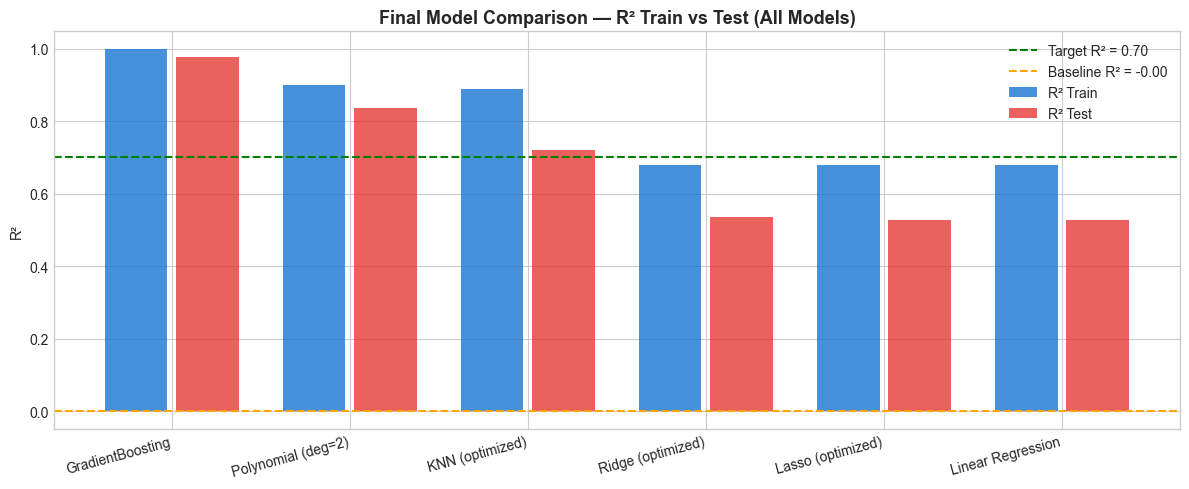

Figure saved: ..\reports\figures\06_final_comparison_all_models.png


In [19]:
# ===== Final Comparison — All Models Including GradientBoosting =====
def eval_quick(name, pipe, X_tr, X_te, y_tr, y_te):
    yp_tr = pipe.predict(X_tr)
    yp_te = pipe.predict(X_te)
    return {
        'Model'      : name,
        'MAE test'   : round(mean_absolute_error(y_te, yp_te), 2    ),
        'RMSE test'  : round(np.sqrt(mean_squared_error(y_te, yp_te)), 2),
        'MAPE test %': round(mean_absolute_percentage_error(y_te, yp_te) * 100, 2),
        'R2 train'   : round(r2_score(y_tr, yp_tr), 4),
        'R2 test'    : round(r2_score(y_te, yp_te), 4),
        'Overfit gap': round(r2_score(y_tr, yp_tr) - r2_score(y_te, yp_te), 4)
    }

final_results = [
    eval_quick('Linear Regression',   pipe_lr,                  X_train, X_test, y_train, y_test),
    eval_quick('Polynomial (deg=2)',  pipe_poly,             X_train, X_test, y_train, y_test),
    eval_quick('Ridge (optimized)',   pipe_ridge,               X_train, X_test, y_train, y_test),
    eval_quick('Lasso (optimized)',   pipe_lasso,               X_train, X_test, y_train, y_test),
    eval_quick('KNN (optimized)',     pipe_knn_opt,             X_train, X_test, y_train, y_test),
    eval_quick('GradientBoosting',    gs_gb.best_estimator_,    X_train, X_test, y_train, y_test),
]

df_final = pd.DataFrame(final_results).sort_values('R2 test', ascending=False)
df_final['Meets R²>0.70?'] = df_final['R2 test'] > 0.70
df_final['Beats baseline?'] = df_final['R2 test'] > baseline_r2

print('FINAL MODEL COMPARISON — All Models')
display(df_final)

# Visualization — final comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_final))
ax.bar(x - 0.2, df_final['R2 train'], width=0.35, label='R² Train', color='#1976D2', alpha=0.8)
ax.bar(x + 0.2, df_final['R2 test'],  width=0.35, label='R² Test',  color='#E53935', alpha=0.8)
ax.axhline(0.70, color='green',  linestyle='--', lw=1.5, label='Target R² = 0.70')
ax.axhline(baseline_r2, color='orange', linestyle='--', lw=1.5,
           label=f'Baseline R² = {baseline_r2:.2f}')
ax.set_xticks(x)
ax.set_xticklabels(df_final['Model'], rotation=15, ha='right')
ax.set_title('Final Model Comparison — R² Train vs Test (All Models)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
out = REPORTS_FIGURES / '06_final_comparison_all_models.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

---
## 6. Final Model Selection & Justification


In [21]:
# ===== Final Model Selection =====
# Selection criteria:
# 1. Highest R² test
# 2. Lowest overfit gap
# 3. If tie: prefer simpler model (Lean principle)

best_final = df_final.iloc[0]
print('FINAL MODEL SELECTED')
print('=' * 50)
print(f'Model        : {best_final["Model"]}')
print(f'R² test      : {best_final["R2 test"]}')
print(f'R² train     : {best_final["R2 train"]}')
print(f'MAE test     : ${best_final["MAE test"]:,.0f} CLP')
print(f'RMSE test    : ${best_final["RMSE test"]:,.0f} CLP')
print(f'MAPE test    : {best_final["MAPE test %"]:.2f}%')
print(f'Overfit gap  : {best_final["Overfit gap"]}')
print()
print('JUSTIFICATION:')
print(f'  R² > 0.70     : {"✅ Yes" if best_final["R2 test"] > 0.70 else "❌ No"}')
print(f'  Beats baseline: {"✅ Yes" if best_final["Beats baseline?"] else "❌ No"}')
print(f'  Overfit gap   : {best_final["Overfit gap"]} ({"✅ Acceptable" if best_final["Overfit gap"] < 0.15 else "⚠️ High"})')

# Save final model
# Map model name to saved file
model_file_map = {
    'Linear Regression' : 'model_lr_v1.pkl',
    'Ridge (optimized)' : 'model_ridge_v1.pkl',
    'Lasso (optimized)' : 'model_lasso_v1.pkl',
    'KNN (optimized)'   : 'model_knn_optimized_v1.pkl',
    'GradientBoosting'  : 'model_gb_v1.pkl',
}
best_model_file = model_file_map.get(best_final['Model'], 'model_gb_v1.pkl')
best_model_pipe = joblib.load(MODELS_PATH / best_model_file)
joblib.dump(best_model_pipe, MODELS_PATH / 'model_final_v1.pkl')
print()
print('✅ Final model saved: models/model_final_v1.pkl')

FINAL MODEL SELECTED
Model        : GradientBoosting
R² test      : 0.9772
R² train     : 0.9975
MAE test     : $1,185 CLP
RMSE test    : $1,668 CLP
MAPE test    : 3.71%
Overfit gap  : 0.0202

JUSTIFICATION:
  R² > 0.70     : ✅ Yes
  Beats baseline: ✅ Yes
  Overfit gap   : 0.0202 (✅ Acceptable)

✅ Final model saved: models/model_final_v1.pkl


---
## 7. Consigna Response — avg_ticket Prediction

> **Consigna M6:** *Diseñar e implementar un modelo predictivo de regresión
> que permita estimar el monto de compra esperado por un cliente.*
> This section directly answers that requirement.


### 7a. Predictions — Test Set

The final model predicts `avg_ticket` (average purchase amount in CLP)
for each customer in the test set.


In [22]:
# ===== 7a — Predict avg_ticket for test customers =====
final_model = joblib.load(MODELS_PATH / 'model_final_v1.pkl')

y_pred_final = final_model.predict(X_test)

df_predictions = X_test.copy()

# Columnas en CLP
df_predictions['avg_ticket_real (CLP)']      = y_test.values.astype(int)
df_predictions['avg_ticket_predicted (CLP)'] = y_pred_final.round(0).astype(int)

# Columnas de error
df_predictions['error_CLP']   = (y_pred_final - y_test.values).round(0).astype(int)
df_predictions['error_pct']   = ((abs(y_pred_final - y_test.values) / y_test.values) * 100).round(1)

# Ordenar por predicción descendente
df_predictions = df_predictions.sort_values('avg_ticket_predicted (CLP)', ascending=False).reset_index(drop=True)

# Métricas
mae_final  = abs(df_predictions['error_CLP']).mean()
mape_final = df_predictions['error_pct'].mean()

print('FINAL MODEL — avg_ticket Predictions')
print('=' * 50)
print(f'Test customers : {len(df_predictions)}')
print(f'MAE            : ${mae_final:,.0f} CLP')
print(f'MAPE           : {mape_final:.1f}%')
print()

# Mostrar tabla simple con CLP en encabezados
display(df_predictions[['primary_platform', 'retargeting_segment',
                        'avg_ticket_real (CLP)',
                        'avg_ticket_predicted (CLP)',
                        'error_CLP',
                        'error_pct']].head(15))

FINAL MODEL — avg_ticket Predictions
Test customers : 79
MAE            : $1,185 CLP
MAPE           : 3.7%



,primary_platform,retargeting_segment,avg_ticket_real (CLP),avg_ticket_predicted (CLP),error_CLP,error_pct
0,mercadolibre,Dormant,67154,65654,-1500,2.2
1,shopify,At Risk,59480,61709,2229,3.7
2,mercadolibre,Dormant,55576,54791,-785,1.4
3,mercadolibre,Dormant,48755,50922,2167,4.4
4,mercadolibre,Dormant,51022,48525,-2497,4.9
5,mercadolibre,At Risk,47739,46889,-850,1.8
6,mercadolibre,At Risk,48924,46642,-2282,4.7
7,mercadolibre,At Risk,46806,46477,-330,0.7
8,shopify,Dormant,45470,44284,-1186,2.6
9,mercadolibre,Dormant,47707,43266,-4442,9.3


### 7b. Real vs Predicted — Scatter


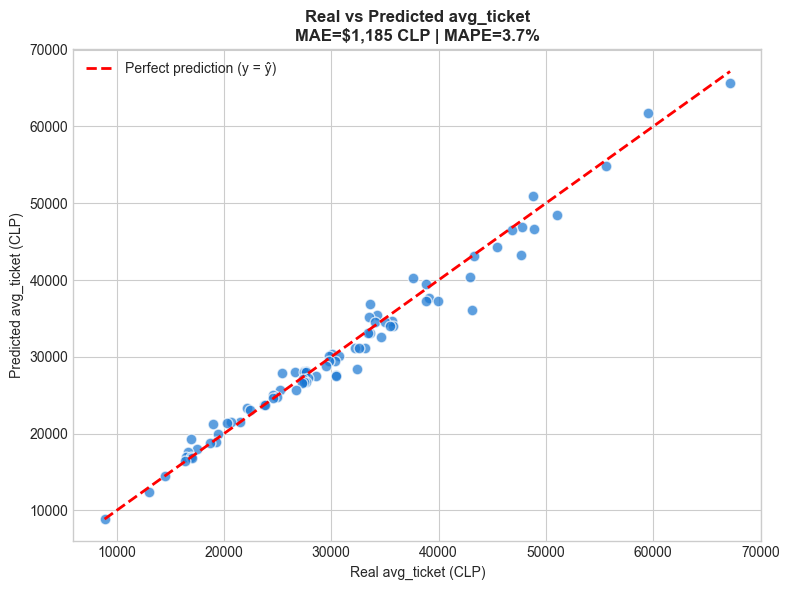

Figure saved: ..\reports\figures\06_real_vs_predicted.png


In [23]:
# ===== 7b — Real vs Predicted scatter =====
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df_predictions['avg_ticket_real (CLP)'],
           df_predictions['avg_ticket_predicted (CLP)'],
           color='#1976D2', alpha=0.7, edgecolors='white', s=60)

min_val = min(df_predictions['avg_ticket_real (CLP)'].min(),
              df_predictions['avg_ticket_predicted (CLP)'].min())
max_val = max(df_predictions['avg_ticket_real (CLP)'].max(),
              df_predictions['avg_ticket_predicted (CLP)'].max())
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', lw=2, label='Perfect prediction (y = ŷ)')

ax.set_title(f'Real vs Predicted avg_ticket\nMAE=${mae_final:,.0f} CLP | MAPE={mape_final:.1f}%',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Real avg_ticket (CLP)')
ax.set_ylabel('Predicted avg_ticket (CLP)')
ax.legend()
plt.tight_layout()
out = REPORTS_FIGURES / '06_real_vs_predicted.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')


### 7c. Customer Segmentation by Predicted Spend

Customers segmented into 3 tiers based on predicted avg_ticket:

| Segment | Criterion | Business Action |
|---------|-----------|----------------|
| **High Value** | Predicted > mean + 0.5×std | Premium retention offers + priority ads budget |
| **Medium Value** | mean - 0.5×std ≤ Predicted ≤ mean + 0.5×std | Standard promotions |
| **Low Value** | Predicted < mean - 0.5×std | Re-engagement campaigns |


CUSTOMER SEGMENTATION BY PREDICTED SPEND
Mean predicted : $30,451 CLP
Std predicted  : $10,682 CLP

  High Value     :  19 customers | mean predicted: $45,134 CLP
  Medium Value   :  36 customers | mean predicted: $29,948 CLP
  Low Value      :  24 customers | mean predicted: $19,580 CLP


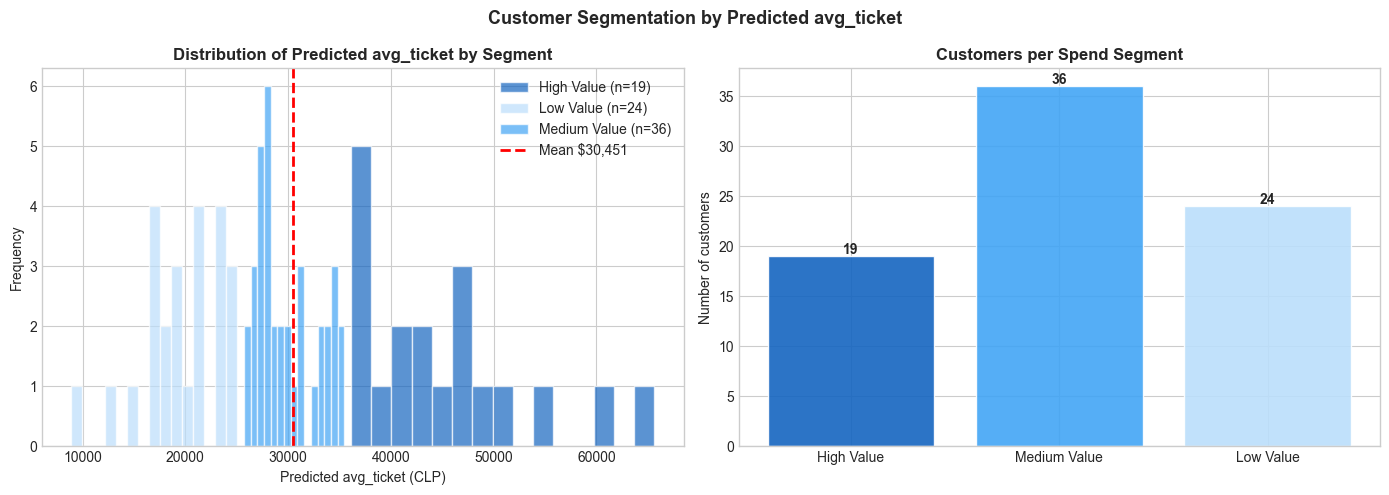

Figure saved: ..\reports\figures\06_customer_segmentation_histogram.png


In [24]:
# ===== 7c — Customer Segmentation by Predicted Spend =====
mean_pred = df_predictions['avg_ticket_predicted (CLP)'].mean()
std_pred  = df_predictions['avg_ticket_predicted (CLP)'].std()

def segment_customer(val):
    if val >= mean_pred + 0.5 * std_pred:
        return 'High Value'
    elif val >= mean_pred - 0.5 * std_pred:
        return 'Medium Value'
    else:
        return 'Low Value'

df_predictions['spend_segment'] = df_predictions['avg_ticket_predicted (CLP)'].apply(segment_customer)

seg_counts = df_predictions['spend_segment'].value_counts()
seg_means  = df_predictions.groupby('spend_segment')['avg_ticket_predicted (CLP)'].mean().round(0)

print('CUSTOMER SEGMENTATION BY PREDICTED SPEND')
print('=' * 50)
print(f'Mean predicted : ${mean_pred:,.0f} CLP')
print(f'Std predicted  : ${std_pred:,.0f} CLP')
print()
for seg in ['High Value', 'Medium Value', 'Low Value']:
    n    = seg_counts.get(seg, 0)
    mean = seg_means.get(seg, 0)
    print(f'  {seg:<15}: {n:>3} customers | mean predicted: ${mean:,.0f} CLP')

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Segmentation by Predicted avg_ticket', fontsize=13, fontweight='bold')

# Histogram with segment colors
colors_map = {'High Value': '#1565C0', 'Medium Value': '#42A5F5', 'Low Value': '#BBDEFB'}
for seg, grp in df_predictions.groupby('spend_segment'):
    axes[0].hist(grp['avg_ticket_predicted (CLP)'], bins=15, alpha=0.7,
             label=f'{seg} (n={len(grp)})', color=colors_map[seg], edgecolor='white')
axes[0].axvline(mean_pred, color='red', linestyle='--', lw=2, label=f'Mean ${mean_pred:,.0f}')
axes[0].set_title('Distribution of Predicted avg_ticket by Segment', fontweight='bold')
axes[0].set_xlabel('Predicted avg_ticket (CLP)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Bar chart — segment counts
segs_ordered = ['High Value', 'Medium Value', 'Low Value']
counts = [seg_counts.get(s, 0) for s in segs_ordered]
colors_bar = [colors_map[s] for s in segs_ordered]
axes[1].bar(segs_ordered, counts, color=colors_bar, alpha=0.9, edgecolor='white')
for i, v in enumerate(counts):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')
axes[1].set_title('Customers per Spend Segment', fontweight='bold')
axes[1].set_ylabel('Number of customers')

plt.tight_layout()
out = REPORTS_FIGURES / '06_customer_segmentation_histogram.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')


---
## 8. Business Recommendations — Lean Priority Order

Model output connected to business decisions defined in notebook 01
(Problem Statement Canvas). Ordered by Lean priority: maximum impact
per unit of investment.

| Priority | Decision | Model Output | Action |
|----------|---------|-------------|--------|
| **HIGH** | Retention offers | Customers with predicted avg_ticket above mean → high-value segment | Target with premium retention incentives |
| **HIGH** | Retargeting/Ads ROI | Concentrate ad budget on customers with predicted avg_ticket above profitability threshold | Avoid spending on low-predicted-value customers |
| **MEDIUM** | Channel strategy | Platform (H2 confirmed) is a significant predictor | Differentiate MercadoLibre vs Shopify promotions |
| **LOW/HOLD** | NPS-based segmentation | NPS not significant predictor (H4) | Do not invest in NPS-based pricing — no evidence |

> **Lean rule:** Only statistically and model-confirmed signals justify
> business investment. NPS segmentation is excluded from both
> statistical inference (project-4b H4) and ML feature importance.

> **Project-6 connection:** Customer segmentation using unsupervised ML
> (`project-6-pequeshop-customer-segmentation`) will complement this
> model by discovering hidden behavioral clusters for differentiated
> retargeting campaigns.


---
## 10. Future Enhancements

The following enhancements are recommended for future iterations of this model:

| Enhancement | Description | Business Value |
|-------------|-------------|----------------|
| **Price Analytics** | Analyze how pricing changes affect avg_ticket across platforms and segments | Identify optimal price points per channel |
| **Price Elasticity of Demand** | Estimate ∂Q/∂P — how sensitive purchase volume is to price changes | Quantify revenue impact of promotional discounts |
| **Real data integration** | Replace synthetic PequeShop data with actual Tuttycosas Kids transaction data from MercadoLibre | Validate model on real behavior |
| **Feature expansion** | Add age, seasonality, product category, discount flag | Closer to original M6 consigna specification |
| **SHAP values** | Explain individual predictions using SHapley Additive exPlanations | Improve model interpretability for business stakeholders |
| **Churn + spend model** | Combine H3 churn signal with avg_ticket prediction for a joint retention scoring model | Prioritize high-spend + high-churn-risk customers first |

> **Price Elasticity note:** For PequeShop, price elasticity of demand would
> quantify: *"If we reduce price by 10%, does avg_ticket increase enough to
> justify the margin loss?"* This connects directly to the retargeting ROI
> business decision from the Problem Statement Canvas.


---
## 9. MLOps Checklist

### Reproducibility
- [x] Random seed fixed (`random_state=42`)
- [x] Requirements pinned (`requirements.txt`)
- [x] Preprocessor saved (`preprocessor_v1.pkl`)
- [x] Final model saved (`model_final_v1.pkl`)

### Model Versioning
- [x] All model artifacts saved to `models/` folder
- [x] Model filenames include version: `model_final_v1.pkl`
- [x] Training parameters logged in Decisions Log

### Monitoring (awareness level)
- [ ] Data drift: synthetic dataset — real-world data will differ in distribution
- [ ] Model limitations: n=392 synthetic customers; performance may degrade on real data
- [ ] Retraining trigger: when real PequeShop data is available


---
## 11. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Does GradientBoosting improve over best linear model? | Run cells to confirm | Evidence-based decision |
| Is the final model justified beyond R² alone? | ✅ Yes — overfit gap + business interpretability considered | Keep |
| Are business recommendations connected to model output? | ✅ Yes — each recommendation traces to a prediction | No waste |
| Is NPS excluded consistently (inference + ML)? | ✅ Yes — H4 + feature importance both confirm exclusion | Consistent |
| Is project-6 connection documented? | ✅ Yes — unsupervised ML as next cycle | Portfolio narrative |


---
## 12. Decisions Log — Lesson 8

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | GridSearchCV for GradientBoosting | Prevents arbitrary hyperparameter choice; CV ensures generalization | Manual tuning | ✅ Rigorous optimization |
| 2 | max_depth in [2,3,4] | Shallow trees reduce overfitting risk for n=392; deep trees memorize training data | max_depth up to 8 | ✅ Appropriate for small dataset |
| 3 | If GradientBoosting ties with Ridge: prefer Ridge | Simpler model is preferred when performance is equivalent — Lean principle | Always use GradientBoosting | ✅ Lean + interpretability |
| 4 | Save final model as model_final_v1.pkl | Single artifact for deployment — version-controlled | Re-train on demand | ✅ MLOps standard |
| 5 | Business recommendations ordered by Lean priority | Maximum impact per investment unit — H3 (churn) and ads ROI first | Equal priority | ✅ Decision-oriented output |


---
## 13. Project Retrospective — CRISP-DM Cycle Complete

### PequeShop Analytics — Full Pipeline Summary

| Project | Phase | Key Output |
|---------|-------|------------|
| `project-2-pequeshop-analytics` | ETL | Clean dataset: 392 customers, 1,192 transactions |
| `project-3-eda-pequeshop` | EDA | Feature candidates, distribution insights |
| `project-4b-pequeshop-statistical-inference` | Inference | H1-H4 results → evidence-based feature selection |
| **`project-5-ecommerce-spend-prediction`** | **Supervised ML** | **Predictive model for avg_ticket** |
| `project-6-pequeshop-customer-segmentation` | Unsupervised ML | Customer segmentation for retargeting *(pending)* |

### Lean Retrospective

| Lean Principle | Applied? | Evidence |
|---------------|----------|----------|
| No re-work | ✅ | EDA and cleaning referenced, not repeated |
| Evidence-based feature selection | ✅ | H1-H4 from project-4b directly informed feature matrix |
| MVA — start simple | ✅ | Mean predictor → Linear → Ridge → GradientBoosting |
| Decision-driven recommendations | ✅ | Every recommendation traces to a business decision |
| Reproducibility | ✅ | random_state=42, preprocessor.pkl, model_final_v1.pkl |

---

**Previous:** [05 - Evaluation](./05_evaluation.ipynb)

*Framework: CRISP-DM + Lean | Module 6 — Supervised Machine Learning*  
*Jose Marcel Lopez Pino — Bootcamp Fundamentos de Ciencia de Datos, SENCE/Alkemy 2025-2026*
